In [28]:
print("day_5 Groupby")

day_5 Groupby


In [22]:
import pandas as pd
import matplotlib.pyplot as plt

In [5]:
df = pd.read_csv('../data/train.csv')
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [9]:
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [6]:
df.groupby("Survived")["Age"].mean()

Survived
0    30.626179
1    28.343690
Name: Age, dtype: float64

In [8]:
df.groupby("Survived")["Age"].agg(["mean", "median", "count"])

,mean,median,count
Survived,,,
0,30.626179,28.0,424
1,28.343690,28.0,290


In [10]:
df.groupby("Survived")["Age"].agg(lambda x : x.max() - x.min())

Survived
0    73.00
1    79.58
Name: Age, dtype: float64

In [16]:
df.groupby("Survived").agg(
    avg_age=("Age", "mean"),
    median_age=("Age", "median"),
    age_range=("Age",lambda x : x.max() - x.min()),
    passenger_count=("Age", "count")
)

,avg_age,median_age,age_range,passenger_count
Survived,,,,
0,30.626179,28.0,73.00,424
1,28.343690,28.0,79.58,290


In [17]:
df.groupby("Pclass").agg(
    survival_rate=("Survived", "mean"),
    avg_fare=("Fare", "mean"),
    avg_age=("Age", "mean")
)


,survival_rate,avg_fare,avg_age
Pclass,,,
1,0.629630,84.154687,38.233441
2,0.472826,20.662183,29.877630
3,0.242363,13.675550,25.140620


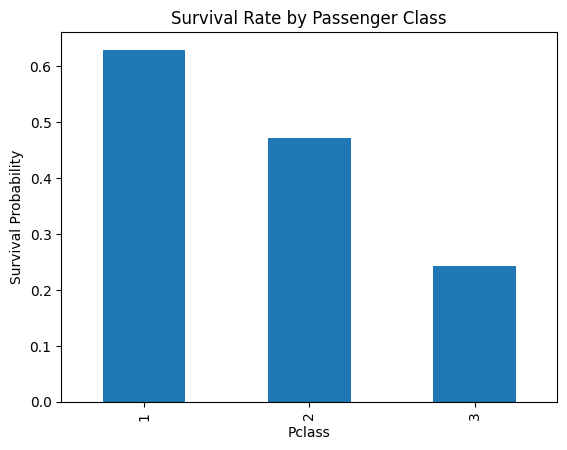

In [23]:
df.groupby("Pclass")["Survived"].mean().plot(kind="bar")
plt.title("Survival Rate by Passenger Class")
plt.ylabel("Survival Probability")
plt.show()

In [27]:
df.groupby("Sex").agg(
    avg_age=("Age", "mean"),
    survival_rate=("Age", "mean"),
    count=("Age", "count")
)

,avg_age,survival_rate,count
Sex,,,
female,27.915709,27.915709,261
male,30.726645,30.726645,453


In [33]:
df.groupby("Pclass").agg(
    max_fare = ("Fare", "max"),
    min_fare = ("Fare", "min"),
    fare_range = ("Fare",lambda x : x.max() - x.min())
)

,max_fare,min_fare,fare_range
Pclass,,,
1,512.3292,0.0,512.3292
2,73.5000,0.0,73.5000
3,69.5500,0.0,69.5500


In [47]:
df["Fare"].value_counts().head(15)

Fare
8.0500     43
13.0000    42
7.8958     38
7.7500     34
26.0000    31
10.5000    24
7.9250     18
7.7750     16
7.2292     15
0.0000     15
26.5500    15
7.8542     13
8.6625     13
7.2500     13
7.2250     12
Name: count, dtype: int64

In [49]:
bins = [0, 12, 18, 35, 60, 100]
labels = ["Child", "Teen", "Young Adult", "Adult", "Senior"]

df["AgeGroup"] = pd.cut(df["Age"], bins=bins, labels=labels)


In [50]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,AgeGroup
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S,Young Adult
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C,Adult
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S,Young Adult
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S,Young Adult
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S,Young Adult


In [53]:
df.groupby("AgeGroup").agg(
    passenger_count=("AgeGroup", "count"),
    survival_rate=("Age", "mean")
)

/tmp/ipykernel_15980/3345024578.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby("AgeGroup").agg(


,passenger_count,survival_rate
AgeGroup,,
Child,69,4.770580
Teen,70,16.578571
Young Adult,358,26.594972
Adult,195,44.830769
Senior,22,66.022727


In [56]:
df.groupby("Embarked").agg(
    avg_fare=("Fare", "mean"),
    mean_age=("Age","mean"),
    median_age=("Age", "median")
)

,avg_fare,mean_age,median_age
Embarked,,,
C,59.954144,30.814769,29.0
Q,13.276030,28.089286,27.0
S,27.079812,29.445397,28.0
